# Taxi Fare Prediction with a GAM

This notebook contains an entire pipeline to predict NYC taxi fare amount
using only non-fare-related trip features by fitting a Generalized Additive Model
(GAM). The notebook loads NYC TLC-style trip data, prepares relevant features,
fits a model, evaluates it, and finally contains some interpretations on the
smooth effects and on the model itself.

### Configuration

Use this code cell to configure the global variables needed for analysis.

`PATH`: Path to parquet file or directory.  
`WORKERS`: Number of workers to use to efficiently read / process data.  
`MAX_ROWS`: Optional **sample size** (number of rows) to randomly draw for analysis (`None` to use all rows)  
- note that if there are `n` files, `MAX_ROWS // n` rows are taken from each file
  create the dataset  

`SEED`: Random seed for reproducibility  
`SPLIT`: Train / validation split fraction (e.g. `0.8` for 80% training)  

In [1]:
PATH = "s3://dsc291-ucsd/taxi/Dataset/2009/yellow_taxi/"
WORKERS = 8
MAX_ROWS = 100000
SEED = 0
SPLIT = 0.8

## Loading and Preparing Data

The following cells load the parquet file(s) from the configured path. Because
NYC TLC data schema differs from year to year, column names are normalized
across varied schema naming conventions. We also want to only read in the
required columns to efficiently utilize memory and reduce computation time.
We can find the columns we need by looking at the defined schemas in the `schemas`
directory for each taxi type.

| Taxi Type | Pickup Datetime | Dropoff Datetime | Trip Distance | Fare Amount | Passenger Count |
|-----------|-----------------|------------------|---------------|-------------|-----------------|
| FHV | pickup_datetime | dropOff_datetime | -- | -- | -- |
| Green | lpep_pickup_datetime | lpep_dropoff_datetime | trip_distance | fare_amount | passenger_count |
| HVFHS | pickup_datetime | dropoff_datetime | trip_miles | base_passenger_fare | -- |
| Yellow | tpep_pickup_datetime | tpep_dropoff_datetime | trip_distance | fare_amount | passenger_count |

Note that `HVFHS` data also contains a `trip_time` data column, however we will
calculate this on our own to keep data processing consistent between taxi types.
Because `FHV` data doesn't contain any relevant trip fare data for our needs,
we will disregard any `FHV` type trips.

Datetimes are parsed to derive trip duration (minutes), as well as the hour 
and day of the week the trip occurred. Any rows with missing or invalid fare,
distance, or duration values are dropped. Finally, the data is randomly split
into the training and testing split with the random seed. 

Our base model does not factor in the actual datetime of the trips. Arguably,
taxi fares should increase across the years due to inflation. Several assumptions
are made for the data from the inputted path consequently:
- data is only about one type of taxi
- data is only from a single year of trips

In [3]:
from __future__ import annotations

from pathlib import Path
from typing import List

import fsspec

def is_s3_path(path: str | Path) -> bool:
    """
    Return True if the path is an S3 URI.
    """
    return str(path).startswith("s3://")

def get_filesystem(path: str | Path):
    """
    Return an fsspec filesystem for local or S3 paths.
    """
    if is_s3_path(path):
        return fsspec.filesystem("s3", anon=True)
    return fsspec.filesystem("file")

def discover_parquet_files(input_path: str | Path) -> List[str]:
    """
    Recursively discover all .parquet files from a local directory or S3 prefix.
    Returns a sorted list of fully-qualified paths.
    """
    input_path = str(input_path)

    if input_path.endswith(".parquet"):
        return [input_path]

    fs = get_filesystem(input_path)

    if is_s3_path(input_path):
        # Remove scheme for fs.walk
        stripped = input_path.replace("s3://", "", 1)
        base = stripped.rstrip("/")
        files = []

        for root, _, filenames in fs.walk(base):
            for name in filenames:
                if name.endswith(".parquet"):
                    files.append(f"s3://{root}/{name}")

    else:
        base = Path(input_path)
        if not base.exists():
            raise FileNotFoundError(f"Input path does not exist: {input_path}")

        files = [
            str(p)
            for p in base.rglob("*.parquet")
            if p.is_file()
        ]

    files.sort()

    if not files:
        raise FileNotFoundError("No Parquet files found under %s", input_path)

    return files

def find_pickup_datetime_col(columns: List[str]) -> str:
    """
    Detect exact pickup datetime column name.
    """
    candidates = [
        "Trip_Pickup_DateTime",
        "lpep_pickup_datetime",
        "pickup_datetime",
        "tpep_pickup_datetime",
    ]
    for cand in candidates:
        if cand in columns:
            return cand
    return None

def find_dropoff_datetime_col(columns: List[str]) -> str:
    """
    Detect exact dropoff datetime column name.
    """
    candidates = [
        "Trip_Dropoff_DateTime",
        "lpep_dropoff_datetime",
        "dropoff_datetime",
        "dropOff_datetime",
        "tpep_dropoff_datetime",
    ]
    for cand in candidates:
        if cand in columns:
            return cand
    return None

def find_fare_col(columns: List[str]) -> str:
    """
    Detect exact fare column name.
    """
    candidates = [
        "Fare_Amt",
        "base_passenger_fare",
        "fare_amount"
    ]
    for cand in candidates:
        if cand in columns:
            return cand
    return None

def find_dist_col(columns: List[str]) -> str:
    """
    Detect exact distance column name.
    """
    candidates = [
        "trip_distance", 
        "Trip_Distance", 
        "trip_miles", 
        "Trip_Miles"
    ]
    for cand in candidates:
        if cand in columns:
            return cand
    return None

def find_passenger_count_col(columns: List[str]) -> str:
    """
    Detect exact passenger count column name.
    """
    candidates = [
        "passenger_count", 
        "Passenger_Count"
    ]
    for cand in candidates:
        if cand in columns:
            return cand
    return None

def infer_taxi_type_from_path(file_path: str | Path) -> str:
    """
    Infer taxi type (yellow, green, fhv, hvfhv) from file path.
    """
    path = str(file_path).lower()
    for taxi in ["yellow", "green", "hvfhv", "fhv"]:
        if taxi in path:
            return taxi
    return "unknown"

In [4]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.fs as fs

from concurrent.futures import ProcessPoolExecutor, as_completed

print("Reading data from:")
print(PATH)

files = discover_parquet_files(PATH)
print(f"Discovered {len(files)} Parquet files.")

def process_file(file: str, max_rows: int=None) -> pd.DataFrame:
    print(f"Starting {file}...")
    schema = pq.read_schema(file, filesystem=get_filesystem(file))
    taxi_type = infer_taxi_type_from_path(file)

    if taxi_type == "fhv":
        print(f"Skipping FHV file {file} since it lacks fare information.")
        return
    elif taxi_type == "unknown":
        print(f"Skipping file {file} since taxi type could not be inferred.")
        return

    pickup_dt_col = find_pickup_datetime_col(schema.names)
    dropoff_dt_col = find_dropoff_datetime_col(schema.names)
    fare_col = find_fare_col(schema.names)
    dist_col = find_dist_col(schema.names)
    if taxi_type in ["yellow", "green"]:
        passenger_col = find_passenger_count_col(schema.names)

    if not pickup_dt_col or not dropoff_dt_col or not fare_col or not dist_col:
        print(f"Skipping file {file} since required columns could not be detected.")
        return

    # Build list of columns to read
    columns_to_read = [pickup_dt_col, dropoff_dt_col, fare_col, dist_col]
    if passenger_col is not None:
        columns_to_read.append(passenger_col)

    # Ensure we have a file path for both S3 and local
    if is_s3_path(file):
        file_path = file[5:]
        filesystem = fs.S3FileSystem(anonymous=True, region="us-west-2")
    else:
        file_path = file
        filesystem = fs.LocalFileSystem()

    print(f"Reading {file}...")
    # Efficiently read only the necessary columns and batch for row reading
    pf = pq.ParquetFile(file_path, filesystem=filesystem)
    if max_rows is None:
        table = pf.read(columns=columns_to_read, use_threads=True)
    else:
        remaining = max_rows
        chunks: list[pa.RecordBatch] = []

        for batch in pf.iter_batches(columns=columns_to_read, use_threads=True):
            if remaining <= 0:
                break
            if batch.num_rows > remaining:
                batch = batch.slice(0, remaining)
            chunks.append(batch)
            remaining -= batch.num_rows
        table = pa.Table.from_batches(chunks)

    rename_map = {
        pickup_dt_col: "pickup_datetime",
        dropoff_dt_col: "dropoff_datetime",
        fare_col: "fare_amount",
        dist_col: "trip_distance"
    }
    if passenger_col is not None:
        rename_map[passenger_col] = "passenger_count"

    print(f"Renaming columns for {file}...")
    table = table.rename_columns([rename_map.get(name, name) for name in table.column_names])
    df = table.to_pandas()

    # append taxi type for later analysis
    df["taxi_type"] = taxi_type
    if taxi_type == "yellow":
        df["taxi_type_code"] = 0
    elif taxi_type == "green":
        df["taxi_type_code"] = 1
    elif taxi_type == "hvfhv":
        df["taxi_type_code"] = 2

    return df

dfs = []
with ProcessPoolExecutor(max_workers=WORKERS) as executor:
    mini_rows = MAX_ROWS // len(files) if MAX_ROWS is not None else None
    futures = [executor.submit(process_file, file, max_rows=mini_rows) for file in files]
    for future in as_completed(futures):
        df = future.result()
        if df is not None:
            dfs.append(df)

if not dfs:
    raise ValueError("No valid Parquet files found with required columns.")
print(f"Successfully read {len(dfs)} DataFrames. Concatenating...")

data = pd.concat(dfs, ignore_index=True)
pd.set_option('display.max_columns', None)
data

Reading data from:
s3://dsc291-ucsd/taxi/Dataset/2009/yellow_taxi/
Discovered 12 Parquet files.


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

In [22]:
# Feature Engineering
# pickup_datetime, dropoff_datetime, fare_amount, trip_distance
# passenger_count (if available)

# Ensure datetime columns are proper datetimes
data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"], errors="coerce")
data["dropoff_datetime"] = pd.to_datetime(data["dropoff_datetime"], errors="coerce")

# Trip duration in minutes
data["trip_duration_min"] = (data["dropoff_datetime"] - data["pickup_datetime"]).dt.total_seconds() / 60.0

# Hour of day and day of week (0=Monday,...,6=Sunday)
data["pickup_hour"] = data["pickup_datetime"].dt.hour
data["pickup_dow"] = data["pickup_datetime"].dt.dayofweek
data["pickup_year"] = data["pickup_datetime"].dt.year
data["pickup_month"] = data["pickup_datetime"].dt.month

year_levels = sorted(data["pickup_year"].unique())
year_map = {y:i for i, y in enumerate(year_levels)}
data["pickup_year_code"] = data["pickup_year"].map(year_map).astype(int)

# Basic cleaning: drop rows with missing key fields
required_cols = [
    "fare_amount",
    "trip_distance",
    "trip_duration_min",
    "pickup_hour",
    "pickup_dow",
]

# passenger_count may be missing for some taxi types; include if present
if "passenger_count" in data.columns:
    required_cols.append("passenger_count")

clean = data.dropna(subset=required_cols).copy()

# Filter out clearly invalid values
clean = clean[(clean["fare_amount"] > 0)]
clean = clean[(clean["trip_distance"] > 0)]
clean = clean[(clean["trip_duration_min"] > 0)]

# Trim extreme outliers using the 99th percentile for key continuous features
quantiles = clean[["fare_amount", "trip_distance", "trip_duration_min"]].quantile(0.99)
clean = clean[clean["fare_amount"] <= quantiles["fare_amount"]]
clean = clean[clean["trip_distance"] <= quantiles["trip_distance"]]
clean = clean[clean["trip_duration_min"] <= quantiles["trip_duration_min"]]

clean.reset_index(drop=True, inplace=True)
clean

,pickup_datetime,dropoff_datetime,fare_amount,trip_distance,passenger_count,taxi_type,taxi_type_code,trip_duration_min,pickup_hour,pickup_dow,pickup_year,pickup_month,pickup_year_code
0,2009-01-04 02:52:00,2009-01-04 03:02:00,8.9,2.63,1,yellow,0,10.000000,2,6,2009,1,0
1,2009-01-04 03:31:00,2009-01-04 03:38:00,12.1,4.55,3,yellow,0,7.000000,3,6,2009,1,0
2,2009-01-03 15:43:00,2009-01-03 15:57:00,23.7,10.35,5,yellow,0,14.000000,15,5,2009,1,0
3,2009-01-01 20:52:58,2009-01-01 21:14:00,14.9,5.00,1,yellow,0,21.033333,20,3,2009,1,0
4,2009-01-24 16:18:23,2009-01-24 16:24:56,3.7,0.40,1,yellow,0,6.550000,16,5,2009,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95581,2009-01-01 14:36:00,2009-01-01 14:49:00,18.1,7.25,3,yellow,0,13.000000,14,3,2009,1,0
95582,2009-01-01 14:52:00,2009-01-01 15:00:00,6.5,1.43,1,yellow,0,8.000000,14,3,2009,1,0
95583,2009-01-17 06:04:00,2009-01-17 06:06:00,3.7,0.54,1,yellow,0,2.000000,6,5,2009,1,0
95584,2009-01-16 18:10:00,2009-01-16 18:19:00,6.5,1.15,1,yellow,0,9.000000,18,4,2009,1,0


In [23]:
clean.describe(include="all")

,pickup_datetime,dropoff_datetime,fare_amount,trip_distance,passenger_count,taxi_type,taxi_type_code,trip_duration_min,pickup_hour,pickup_dow,pickup_year,pickup_month,pickup_year_code
count,95586,95586,95586.000000,95586.000000,95586.000000,95586,95586.0,95586.000000,95586.000000,95586.000000,95586.0,95586.0,95586.0
unique,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,yellow,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,95586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2009-01-17 07:23:25.444468736,2009-01-17 07:33:48.770112768,9.018987,2.412729,1.794363,NaN,0.0,10.388761,13.684933,3.193700,2009.0,1.0,0.0
min,2009-01-01 00:03:40,2009-01-01 00:09:08,2.500000,0.010000,0.000000,NaN,0.0,0.016667,0.000000,0.000000,2009.0,1.0,0.0
25%,2009-01-09 21:06:09.750000128,2009-01-09 21:18:00,5.500000,1.000000,1.000000,NaN,0.0,5.533333,9.000000,2.000000,2009.0,1.0,0.0
50%,2009-01-17 08:38:20.500000,2009-01-17 08:48:47,7.300000,1.650000,1.000000,NaN,0.0,9.000000,15.000000,3.000000,2009.0,1.0,0.0
75%,2009-01-24 19:32:00,2009-01-24 19:44:00,10.500000,2.870000,2.000000,NaN,0.0,13.983333,19.000000,5.000000,2009.0,1.0,0.0
max,2009-01-31 23:59:41,2009-02-01 00:20:35,45.000000,17.220000,6.000000,NaN,0.0,40.000000,23.000000,6.000000,2009.0,1.0,0.0


In [6]:
# Train / Validation Split
from sklearn.model_selection import train_test_split

feature_cols = [
    "trip_distance",
    "trip_duration_min",
    "pickup_hour",
    "pickup_dow",
]
if "passenger_count" in clean.columns:
    feature_cols.append("passenger_count")

X = clean[feature_cols].copy()
y = clean["fare_amount"].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    train_size=SPLIT,
    random_state=SEED,
)

X_train.head()

,trip_distance,trip_duration_min,pickup_hour,pickup_dow,passenger_count
8617,2.44,11.000000,19,5,5
8882,2.12,8.000000,1,5,1
71491,3.20,9.316667,21,6,2
43120,1.19,4.000000,23,2,5
17333,1.90,10.016667,11,3,1


Train RMSE: 1.37, R^2: 0.939
Validation RMSE: 1.21, R^2: 0.951


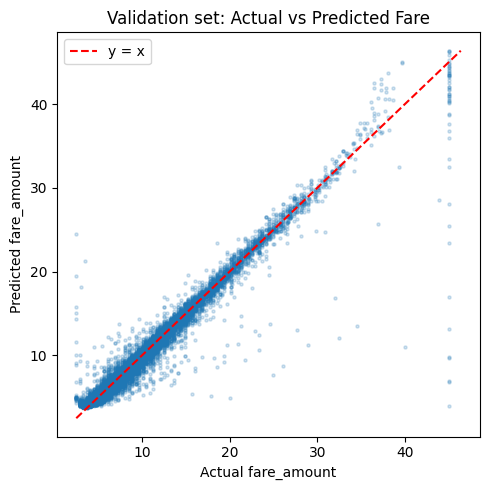

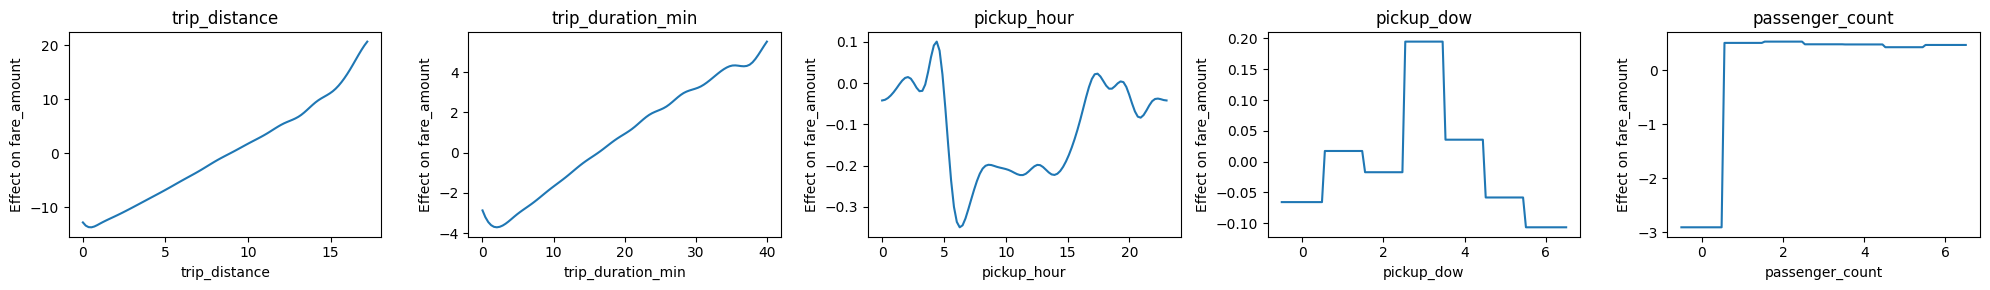

In [ ]:
## Fit a GAM and Evaluate

# If pygam is not installed in your environment, run in a separate cell:
# !pip install pygam

from pygam import LinearGAM, s, f
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Build the GAM: smooth terms for continuous features, factor for passenger_count if present
terms = (
    s(0) +  # trip_distance
    s(1) +  # trip_duration_min
    s(2, basis="cp") +  # pickup_hour (periodic spline)
    f(3)    # pickup_dow (factor)
)

if "passenger_count" in feature_cols:
    # passenger_count is the last column in feature_cols
    terms = terms + f(feature_cols.index("passenger_count"))

gam = LinearGAM(terms).fit(X_train, y_train)

# Predictions
y_pred_train = gam.predict(X_train)
y_pred_val = gam.predict(X_val)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_val = mean_squared_error(y_val, y_pred_val)
rmse_train = np.sqrt(mse_train)
rmse_val = np.sqrt(mse_val)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_val = mean_absolute_error(y_val, y_pred_val)
r2_train = r2_score(y_train, y_pred_train)
r2_val = r2_score(y_val, y_pred_val)

print(f"Train RMSE: {rmse_train:.2f}, MAE: {mae_train:.2f}, R^2: {r2_train:.3f}")
print(f"Validation RMSE: {rmse_val:.2f}, MAE: {mae_val:.2f}, R^2: {r2_val:.3f}")

# Scatter plot: actual vs predicted fare on validation set with y=x reference line
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(y_val, y_pred_val, alpha=0.2, s=5)
lims = [min(y_val.min(), y_pred_val.min()), max(y_val.max(), y_pred_val.max())]
plt.plot(lims, lims, "r--", label="y = x")
plt.xlabel("Actual fare_amount")
plt.ylabel("Predicted fare_amount")
plt.title("Validation set: Actual vs Predicted Fare")
plt.legend()
plt.tight_layout()
plt.show()

# Optional: look at partial dependence plots for each smooth term
fig, axs = plt.subplots(1, len(feature_cols), figsize=(4 * len(feature_cols), 3))

# Make axs iterable even when there's only one feature
if len(feature_cols) == 1:
    axs = [axs]

for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
    lower_ci, upper_ci = confi.T
    ax.plot(XX[:, i], pdep, label="Partial dependence", linewidth=2, color="blue")
    ax.fill_between(XX[:, i], lower_ci, upper_ci, alpha=0.3, label="95% CI", color="blue")
    ax.set_title(feature_cols[i])
    ax.set_xlabel(feature_cols[i])
    ax.set_ylabel("Effect on fare_amount")
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

### Limitations

This GAM model uses only a subset of available trip information (distance, 
duration, time of day, day of week, and passenger count), so it cannot capture 
effects from other important factors like traffic, routing, weather, or special 
events. It also assumes that the historical relationships in this single-year 
sample generalize to other time periods. Our initial assumptions of the data
also limit analysis to one taxi type. Arguably speaking, different taxi types
cover different locations, and thus encounter different fare rates. A future,
more robust model would consider taxi type as a predictor.

### Extra Credit

In [24]:
feature_cols = [
    "trip_distance",
    "trip_duration_min",
    "pickup_hour",
    "pickup_dow",
    "pickup_year_code",
    "pickup_month",
    "taxi_type_code"
]
if "passenger_count" in clean.columns:
    feature_cols.append("passenger_count")

X = clean[feature_cols].copy()
y = clean["fare_amount"].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    train_size=SPLIT,
    random_state=SEED,
)

X_train.head()

,trip_distance,trip_duration_min,pickup_hour,pickup_dow,pickup_year_code,pickup_month,taxi_type_code,passenger_count
8617,2.44,11.000000,19,5,0,1,0,5
8882,2.12,8.000000,1,5,0,1,0,1
71491,3.20,9.316667,21,6,0,1,0,2
43120,1.19,4.000000,23,2,0,1,0,5
17333,1.90,10.016667,11,3,0,1,0,1


Train RMSE: 0.11, R^2: 0.952
Validation RMSE: 0.10, R^2: 0.956


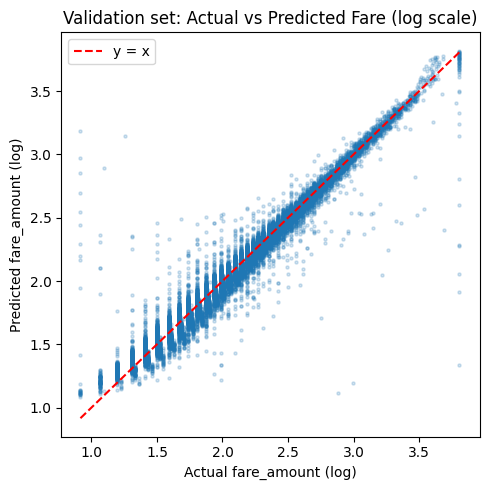

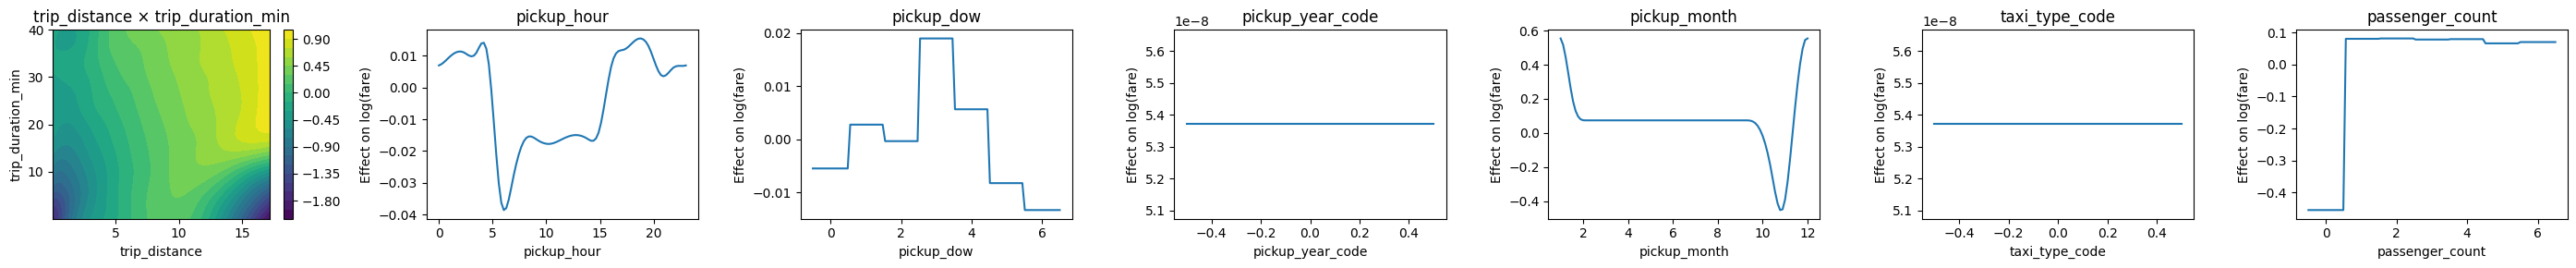

In [ ]:
from pygam import te

terms = (
    te(0, 1, n_splines=[15, 15]) +         # distance x duration surface
    s(2, basis="cp", edge_knots=[0, 23]) + # pickup_hour (cyclic)
    f(3) +                                 # pickup_dow (factor)
    f(4) +                                 # pickup_year_code (factor)
    s(5, basis="cp", edge_knots=[1, 12]) + # pickup_month (cyclic)
    f(6)                                   # taxi_type_code (factor)
)

if "passenger_count" in feature_cols:
    # passenger_count is the last column in feature_cols
    terms = terms + f(feature_cols.index("passenger_count"))

y_train_log = np.log(y_train)
gam_ec = LinearGAM(terms).fit(X_train, y_train_log)

# Predictions
y_pred_train = gam_ec.predict(X_train)
y_pred_val = gam_ec.predict(X_val)

y_val_log = np.log(y_val)

mse_train = mean_squared_error(y_train_log, y_pred_train)
mse_val = mean_squared_error(y_val_log, y_pred_val)
mae_train = mean_absolute_error(y_train_log, y_pred_train)
mae_val = mean_absolute_error(y_val_log, y_pred_val)
rmse_train = np.sqrt(mse_train)
rmse_val = np.sqrt(mse_val)
r2_train = r2_score(y_train_log, y_pred_train)
r2_val = r2_score(y_val_log, y_pred_val)

print(f"Train RMSE: {rmse_train:.2f}, MAE: {mae_train:.2f}, R^2: {r2_train:.3f}")
print(f"Validation RMSE: {rmse_val:.2f}, MAE: {mae_val:.2f}, R^2: {r2_val:.3f}")

# Scatter plot: actual vs predicted fare on validation set with y=x reference line
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(y_val_log, y_pred_val, alpha=0.2, s=5)
lims = [min(y_val_log.min(), y_pred_val.min()), max(y_val_log.max(), y_pred_val.max())]
plt.plot(lims, lims, "r--", label="y = x")
plt.xlabel("Actual fare_amount (log)")
plt.ylabel("Predicted fare_amount (log)")
plt.title("Validation set: Actual vs Predicted Fare (log scale)")
plt.legend()
plt.tight_layout()
plt.show()

n_terms = len(gam_ec.terms)
term_ids = [t for t in range(n_terms) if not gam_ec.terms[t].isintercept]

fig, axs = plt.subplots(1, len(term_ids), figsize=(4 * len(term_ids), 3))
if len(term_ids) == 1:
    axs = [axs]

for ax, term_id in zip(axs, term_ids):

    term_obj = gam_ec.terms[term_id]

    # -------- Tensor term (distance x duration) --------
    if term_obj.istensor:

        # Get feature indices used in tensor
        feat_idxs = term_obj.feature  # usually a tuple like (0, 1)
        feat_names = [feature_cols[i] for i in feat_idxs]

        XX = gam_ec.generate_X_grid(term=term_id, n=50, meshgrid=True)
        Z = gam_ec.partial_dependence(term=term_id, X=XX, meshgrid=True)
        xg, yg = XX

        cs = ax.contourf(xg, yg, Z, levels=20)
        ax.set_xlabel(feat_names[0])
        ax.set_ylabel(feat_names[1])
        ax.set_title(f"{feat_names[0]} × {feat_names[1]}")
        fig.colorbar(cs, ax=ax)

    # -------- 1D smooth or factor --------
    else:
        feat_idx = term_obj.feature
        feat_name = feature_cols[feat_idx]

        XX = gam_ec.generate_X_grid(term=term_id)
        pdep, confi = gam_ec.partial_dependence(term=term_id, X=XX, width=0.95)
        lower_ci, upper_ci = confi.T
        ax.plot(XX[:, feat_idx], pdep, label="Partial dependence", linewidth=2, color="blue")
        ax.fill_between(XX[:, feat_idx], lower_ci, upper_ci, alpha=0.3, label="95% CI", color="blue")
        ax.set_title(feat_name)
        ax.set_xlabel(feat_name)
        ax.set_ylabel("Effect on log(fare_amount)")
        if term_id == 1:
            ax.legend()

plt.tight_layout()
plt.show()